Task 2: Custom Weight Initialization & Gradient Vanishing Analysis

In [ ]:

import torch
import numpy as np
import matplotlib.pyplot as plt

# Disable Autograd
torch.set_grad_enabled(False)

 Xavier Initialization

In [1]:
def xavier_init(in_features, out_features):
    limit = np.sqrt(6 / (in_features + out_features))
    return torch.empty(in_features, out_features).uniform_(-limit, limit)

He Initialization

In [2]:
def he_init(in_features, out_features):
    std = np.sqrt(2 / in_features)
    return torch.randn(in_features, out_features) * std


Create 20-Layer MLP

In [5]:
import torch

input_size = 100
hidden_size = 100
num_layers = 20
batch_size = 64

# Random Input
X = torch.randn(batch_size, input_size)

Function to Track Activations

In [6]:
def analyze_network(init_type):

    activations_mean = []
    activations_var = []

    A = X

    for i in range(num_layers):

        if init_type == "Xavier":
            W = xavier_init(hidden_size, hidden_size)
        else:
            W = he_init(hidden_size, hidden_size)

        # First layer
        if i == 0:
            if init_type == "Xavier":
                W = xavier_init(input_size, hidden_size)
            else:
                W = he_init(input_size, hidden_size)

        A = torch.matmul(A, W)
        A = torch.relu(A)

        activations_mean.append(A.mean().item())
        activations_var.append(A.var().item())

    return activations_mean, activations_var


Analyze Xavier

In [8]:
import numpy as np
x_mean, x_var = analyze_network("Xavier")

Analyze He

In [11]:
h_mean, h_var = analyze_network("He")

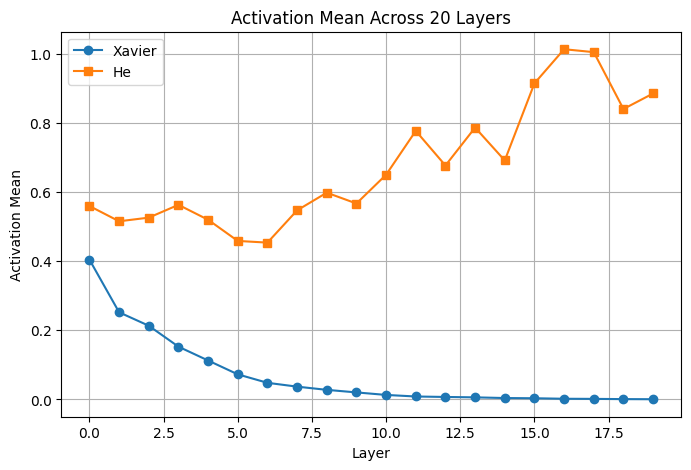

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(x_mean, marker='o', label="Xavier")
plt.plot(h_mean, marker='s', label="He")
plt.xlabel("Layer")
plt.ylabel("Activation Mean")
plt.title("Activation Mean Across 20 Layers")
plt.legend()
plt.grid(True)
plt.show()

Plot Variance

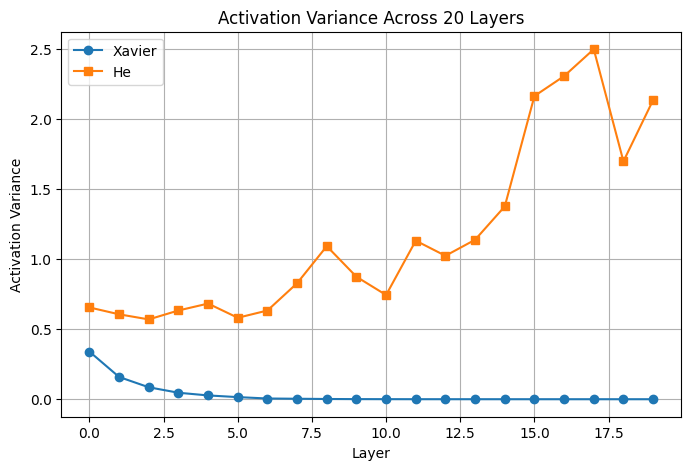

In [13]:
plt.figure(figsize=(8,5))
plt.plot(x_var, marker='o', label="Xavier")
plt.plot(h_var, marker='s', label="He")
plt.xlabel("Layer")
plt.ylabel("Activation Variance")
plt.title("Activation Variance Across 20 Layers")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
print("\nXavier Mean:")
print(x_mean)

print("\nXavier Variance:")
print(x_var)

print("\nHe Mean:")
print(h_mean)

print("\nHe Variance:")
print(h_var)


Xavier Mean:
[0.40480247139930725, 0.25230538845062256, 0.21338219940662384, 0.1527317762374878, 0.11266595870256424, 0.07256965339183807, 0.04803171008825302, 0.036953698843717575, 0.0276603102684021, 0.020239610224962234, 0.012934676371514797, 0.008411914110183716, 0.00705140782520175, 0.005922191310673952, 0.003958075772970915, 0.0033043285366147757, 0.0018397730309516191, 0.001484886510297656, 0.0008483261335641146, 0.0005133412778377533]

Xavier Variance:
[0.33945971727371216, 0.15858317911624908, 0.08519867062568665, 0.04619597643613815, 0.02703438699245453, 0.01505522895604372, 0.00513048842549324, 0.0033482667058706284, 0.001660579233430326, 0.0007757185958325863, 0.00044130501919426024, 0.00017350884445477277, 0.00013101082004141062, 7.833593554096296e-05, 3.476807614788413e-05, 2.1291238226694986e-05, 6.65118386677932e-06, 4.104701474716421e-06, 1.8274203057444538e-06, 6.542495043504459e-07]

He Mean:
[0.5602130889892578, 0.5159688591957092, 0.5265696048736572, 0.56362098455